## **Assignment Simple machine Learning Project cycle**

### **_House Price Prediction Using California Housing Data_**
This dataset provides information about house prices in California. House Price Prediction


**In this notebook, you'll follow the basic machine learning process to build a regression model to predict house prices using the "California Housing Dataset" from sklearn.**



---



### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a regression model.**


The following is a description of each column in the dataset:

Dataset Features (California Housing):
* MedInc: Median income in block group
* HouseAge: Median house age in block group
* AveRooms: Average number of rooms per household
* AveBedrms: Average number of bedrooms per household
* Population: Block group population
* AveOccup: Average number of household members
* Latitude: Block group latitude
* Longitude: Block group longitude
* MedHouseVal (Target): Median house value in block group




## Mashiur Rahman 

## Assignment 6: House Price Prediction Using California Housing Data

### 1. Import Required Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## 2. Data Collection and Loading

In [6]:
# Load the dataset
housing = fetch_california_housing()

# Convert the dataset into a DataFrame
df = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)

# Add the target column
df["MedHouseVal"] = housing.target

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

Dataset loaded successfully.
Dataset shape: (20640, 9)


## 3. Display the First Five Rows

In [7]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


###  Check Dataset Information

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


### Identify the Features and Target

In [9]:
print("Independent features:")
print(housing.feature_names)

print("\nTarget variable:")
print("MedHouseVal")

Independent features:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target variable:
MedHouseVal


## 4. EDA and Data Preprocessing

####  Check for Missing Values

In [10]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

### Create a Scatter Plot

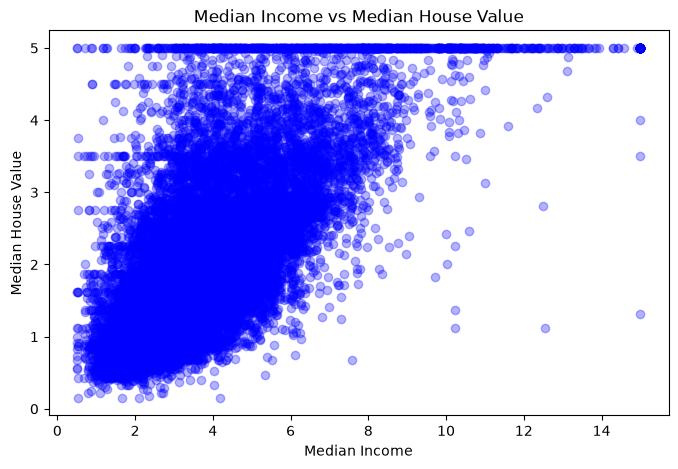

In [11]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["MedInc"],
    df["MedHouseVal"],
    alpha=0.3,
    color="blue"
)

plt.title("Median Income vs Median House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

### Create a Function for Multiple Scatter Plots

In [13]:
def create_scatter_plots(data, features, target):
    
    plt.figure(figsize=(12, 8))
    
    for position, feature in enumerate(features, start=1):
        
        plt.subplot(2, 2, position)
        plt.scatter(
            data[feature],
            data[target],
            alpha=0.3
        )
        
        plt.title(f"{feature} vs {target}")
        plt.xlabel(feature)
        plt.ylabel(target)
    
    plt.tight_layout()
    plt.show()

### Use the Scatter Plot Function

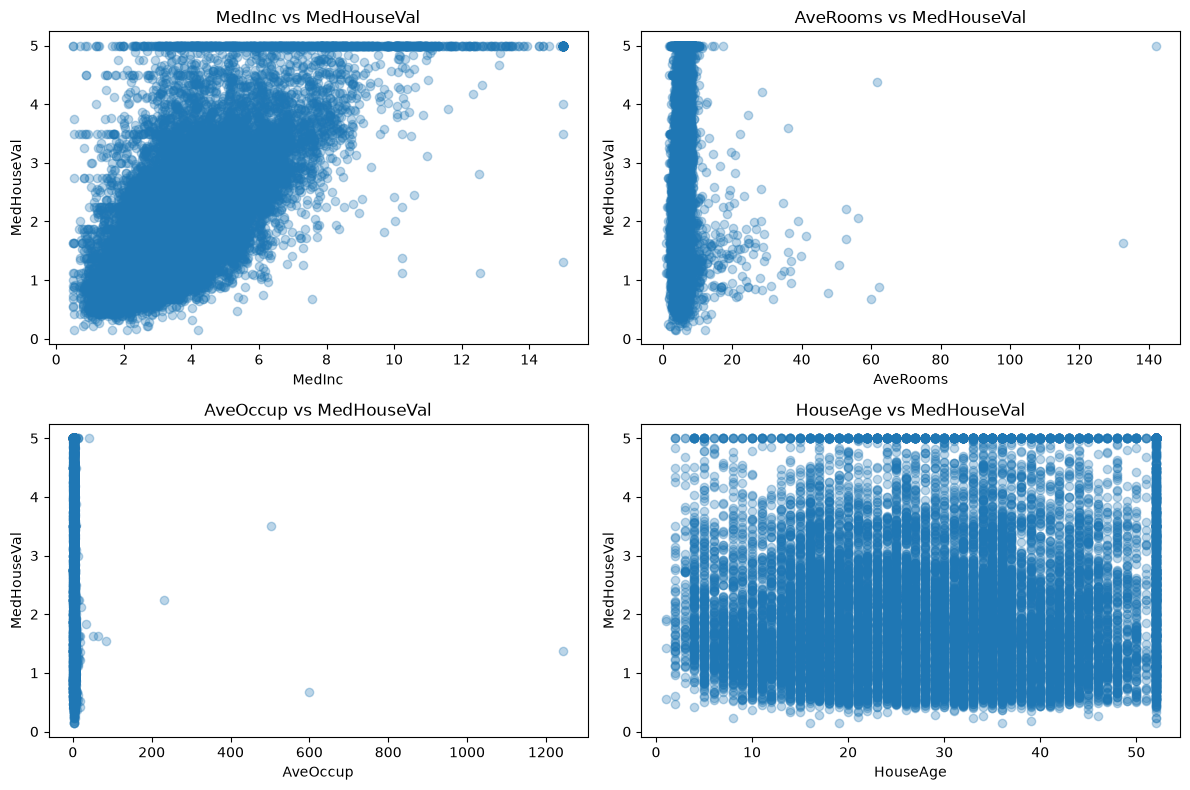

In [14]:
selected_features = [
    "MedInc",
    "AveRooms",
    "AveOccup",
    "HouseAge"
]

create_scatter_plots(
    df,
    selected_features,
    "MedHouseVal"
)

## 5. ML Model Training

### Separate the Features and Target

In [15]:
# Independent features
X = df.drop("MedHouseVal", axis=1)

# Target variable
y = df["MedHouseVal"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (20640, 8)
Target shape: (20640,)


### Split the Dataset

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (16512, 8)
Testing data shape: (4128, 8)


### Create the Linear Regression Model

In [17]:
model = LinearRegression()

print("Linear Regression model created.")

Linear Regression model created.


### Train the Model

In [18]:
model.fit(X_train, y_train)

print("Model training completed.")

Model training completed.


## 6. Model Evaluation

### Make Predictions on the Test Data

In [19]:
y_pred = model.predict(X_test)

print("Predictions completed.")
print(y_pred[:5])

Predictions completed.
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]


### Calculate the Evaluation Metrics

In [20]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", round(mse, 4))
print("Root Mean Squared Error:", round(rmse, 4))
print("R-squared:", round(r2, 4))

Mean Squared Error: 0.5559
Root Mean Squared Error: 0.7456
R-squared: 0.5758


### Compare Actual and Predicted Values

In [21]:
comparison = pd.DataFrame({
    "Actual Value": y_test.iloc[:10].values,
    "Predicted Value": y_pred[:10]
})

comparison

,Actual Value,Predicted Value
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


## 7. Model Prediction

### Predict the Price of a New House

In [22]:
new_house = pd.DataFrame({
    "MedInc": [3],
    "HouseAge": [30],
    "AveRooms": [6],
    "AveBedrms": [1],
    "Population": [1500],
    "AveOccup": [3],
    "Latitude": [34],
    "Longitude": [-118]
})

new_house

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,3,30,6,1,1500,3,34,-118


### Make the Final Prediction

In [23]:
# Arrange the columns in the same order as the training data
new_house = new_house[X.columns]

# Predict the median house value
predicted_value = model.predict(new_house)[0]

print(
    "Predicted Median House Value:",
    round(predicted_value, 4)
)

print(
    "Approximate Predicted House Price: $",
    round(predicted_value * 100000, 2)
)

Predicted Median House Value: 1.5487
Approximate Predicted House Price: $ 154866.33


In [4]:


# --- Imports ---
# TODO: Import all the necessary libraries for data handling, visualization, and model building.
# Example: import pandas as pd
# Add your imports here:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# --- Data Collection and Loading ---
# TODO: Load the 'California Housing' dataset from sklearn and convert it into a pandas DataFrame.
# Hint: Use `fetch_california_housing()` from `sklearn.datasets`

# Load dataset and convert to DataFrame:

# Add your code here:


# --- Quick Check of Data ---
# TODO: Display the first few rows of the dataset to understand its structure.
# Hint: Use `.head()` to inspect the first few rows.

# Add your code here:


# TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
# Hint: Use `.info()` and `.describe()` to inspect data types and statistical properties.

# Add your code here:


# --- EDA and Data Preprocessing ---
# TODO: Check for missing/null values.
# Hint: Use `.isnull().sum()` to check for null values.

# Add your code here:


# TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable (MedHouseVal).
# Example: Use `plt.scatter()` to visualize the relationship between 'MedInc' and 'MedHouseVal'.

# Add your code here:


# TODO: Create a function to automate scatter plots for all features vs MedHouseVal.
# Hint: The function should loop over a list of features and plot scatter plots for each.

# Define your function here:


# TODO: Use the function to visualize the relationships between multiple features and the target variable.
# Features: ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']
# Target: 'MedHouseVal'

# Add your code here:


# --- ML Model Training ---
# TODO: Split the dataset into training and testing sets.
# Hint: Use `train_test_split()` from `sklearn.model_selection` with an 80/20 split.

# Define X (features) and y (target) and perform the train-test split:


# TODO: Choose an appropriate regression model.
# Hint: Use `LinearRegression()` from `sklearn.linear_model`.

# Define your regression model here:


# TODO: Train the model on the training data.
# Hint: Use `.fit()` to train the model.

# Add your code here:


# --- Model Evaluation ---
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
# Hint: Use `mean_squared_error()` and `r2_score()` from `sklearn.metrics`.

# Predict on the test set and calculate the evaluation metrics:


# --- Model Prediction ---
# TODO: Predict Median House Value from a new set of feature inputs.
# Example new data: 'MedInc' = 3, 'HouseAge' = 30, 'AveRooms' = 6, 'AveOccup' = 3, 'Latitude' = 34, 'Longitude' = -118, 'AveBedrms' = 1, 'Population' = 1500
# Hint: Use `.predict()` on a new data array.

# Add your prediction code here:



